In [1]:
# ============================================
# 0) Drive + Imports + Config
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import os, json, random, time, math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import torchvision.transforms as T

Mounted at /content/drive


In [2]:
# -----------------------------
# Repro
# -----------------------------
SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [3]:
# -----------------------------
# Paths (keep your structure)
# -----------------------------
DATA_DIR   = "/content/drive/MyDrive/TASK01/data/"
IMAGE_ROOT = "/content/drive/MyDrive/TASK01/data/"

TRAIN_CSV = os.path.join(DATA_DIR, "train_with_clean_text_RAW_dupes_gaps.csv")
DEV_CSV   = os.path.join(DATA_DIR, "dev_with_clean_text_RAW_dupes_gaps.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test_with_clean_text_RAW_dupes_gaps.csv")

OUT_DIR = "/content/drive/MyDrive/TASK01/models/custom_task1a_image_fromscratch_v2"
os.makedirs(OUT_DIR, exist_ok=True)
print("OUT_DIR:", OUT_DIR)

OUT_DIR: /content/drive/MyDrive/TASK01/models/custom_task1a_image_fromscratch_v2


In [4]:
# ============================================
# 1) Load CSVs + Sanity checks
# ============================================
train_df = pd.read_csv(TRAIN_CSV)
dev_df   = pd.read_csv(DEV_CSV)
test_df  = pd.read_csv(TEST_CSV)

REQ_COLS = ["image", "label_image"]
for c in REQ_COLS:
    assert c in train_df.columns and c in dev_df.columns and c in test_df.columns, f"Missing column {c}"

print("Sizes:", len(train_df), len(dev_df), len(test_df))
print("Nulls train:\n", train_df[REQ_COLS].isna().sum())

LABEL_MAP = {"not_informative": 0, "informative": 1}
ID2LABEL = {v:k for k,v in LABEL_MAP.items()}

def add_label_id(df):
    df = df.copy()
    df["label_image"] = df["label_image"].astype(str).str.strip().str.lower()
    df["label_image_id"] = df["label_image"].map(LABEL_MAP)
    return df

train_df = add_label_id(train_df).dropna(subset=["label_image_id"]).copy()
dev_df   = add_label_id(dev_df).dropna(subset=["label_image_id"]).copy()
test_df  = add_label_id(test_df).dropna(subset=["label_image_id"]).copy()

train_df["label_image_id"] = train_df["label_image_id"].astype(int)
dev_df["label_image_id"]   = dev_df["label_image_id"].astype(int)
test_df["label_image_id"]  = test_df["label_image_id"].astype(int)

def full_path(rel): return os.path.join(IMAGE_ROOT, str(rel))

def drop_missing(df):
    mask = df["image"].astype(str).apply(lambda p: os.path.isfile(full_path(p)))
    missing = (~mask).sum()
    if missing:
        print("Dropped missing:", missing)
    return df[mask].copy()

train_df = drop_missing(train_df)
dev_df   = drop_missing(dev_df)
test_df  = drop_missing(test_df)

def label_stats(df, name):
    vc = df["label_image_id"].value_counts().sort_index()
    total = len(df)
    print(f"\n{name} label distribution:")
    for k,v in vc.items():
        print(f"  {k} ({ID2LABEL[k]}): {v} ({v/total:.2%})")

label_stats(train_df,"TRAIN")
label_stats(dev_df,"DEV")
label_stats(test_df,"TEST")

# Leakage check (by image path)
train_set = set(train_df["image"].astype(str))
dev_set   = set(dev_df["image"].astype(str))
test_set  = set(test_df["image"].astype(str))
print("\nLeak overlaps:", len(train_set&dev_set), len(train_set&test_set), len(dev_set&test_set))

Sizes: 2868 636 632
Nulls train:
 image          0
label_image    0
dtype: int64

TRAIN label distribution:
  0 (not_informative): 1625 (56.66%)
  1 (informative): 1243 (43.34%)

DEV label distribution:
  0 (not_informative): 374 (58.81%)
  1 (informative): 262 (41.19%)

TEST label distribution:
  0 (not_informative): 360 (56.96%)
  1 (informative): 272 (43.04%)

Leak overlaps: 0 0 0


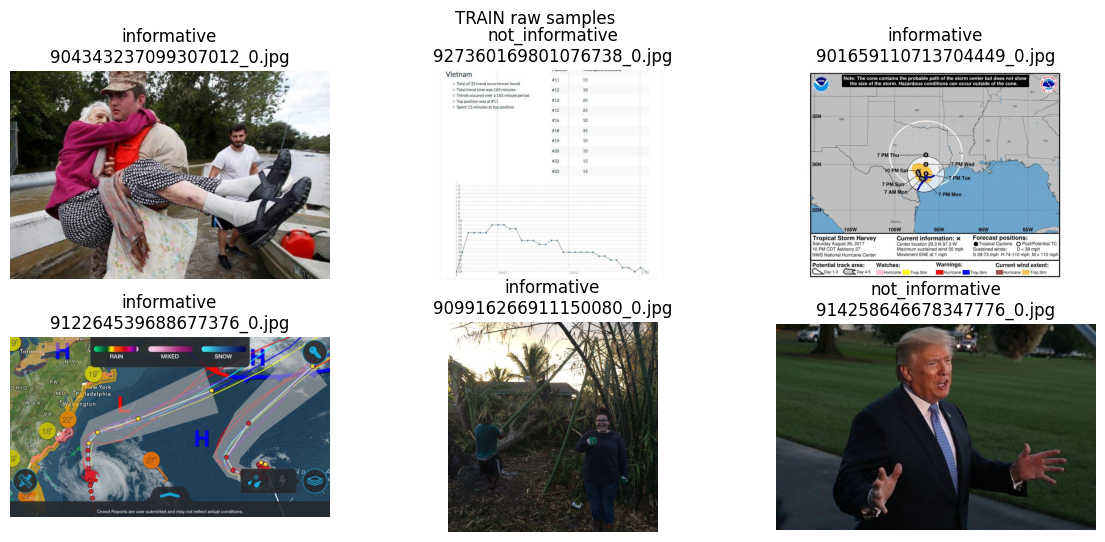

In [5]:
# ============================================
# 2) Visual sanity samples
# ============================================
def show_samples(df, n=6, title="Samples"):
    idxs = np.random.choice(len(df), size=min(n, len(df)), replace=False)
    plt.figure(figsize=(14, 6))
    for i, idx in enumerate(idxs, 1):
        rel = df.iloc[idx]["image"]
        y   = int(df.iloc[idx]["label_image_id"])
        fp  = full_path(rel)
        img = Image.open(fp).convert("RGB")
        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.title(f"{ID2LABEL[y]}\n{os.path.basename(fp)}")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_samples(train_df, title="TRAIN raw samples")

In [6]:
# ============================================
# 3) Preprocessing / Augmentations (safer + researchy)
#   - Remove random-color erasing
#   - Add light perspective + blur
# ============================================
IMG_SIZE = 224

train_tfms = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.80, 1.0), ratio=(0.90, 1.10)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([T.ColorJitter(0.2, 0.2, 0.2, 0.05)], p=0.6),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2))], p=0.2),
    T.RandomPerspective(distortion_scale=0.15, p=0.2),
    T.RandomRotation(degrees=5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    # softer erasing (optional)
    T.RandomErasing(p=0.10, scale=(0.01, 0.04), ratio=(0.3, 3.3), value=0),
])

eval_tfms = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

In [7]:
# ============================================
# 4) Dataset
# ============================================
class ImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        rel = str(self.df.loc[idx, "image"])
        y   = int(self.df.loc[idx, "label_image_id"])
        fp  = full_path(rel)

        try:
            img = Image.open(fp).convert("RGB")
        except:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0,0,0))

        x = self.transform(img)
        return x, y

train_ds = ImageDataset(train_df, train_tfms)
dev_ds   = ImageDataset(dev_df,   eval_tfms)
test_ds  = ImageDataset(test_df,  eval_tfms)

x0, y0 = train_ds[0]
print("Sample:", x0.shape, x0.dtype, y0, ID2LABEL[y0])

Sample: torch.Size([3, 224, 224]) torch.float32 1 informative


In [8]:
# ============================================
# 5) Loaders + imbalance (choose ONE approach)
#   We use WeightedRandomSampler and NORMAL loss.
# ============================================
BATCH_SIZE = 64 if torch.cuda.is_available() else 32
NUM_WORKERS = 2

counts = train_df["label_image_id"].value_counts().sort_index()
class_counts = counts.values.astype(np.float32)
class_weights = 1.0 / class_counts
sample_weights = train_df["label_image_id"].apply(lambda c: class_weights[int(c)]).values

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

pin = torch.cuda.is_available()
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=pin,
    persistent_workers=(NUM_WORKERS>0)
)
dev_loader = DataLoader(
    dev_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin,
    persistent_workers=(NUM_WORKERS>0)
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin,
    persistent_workers=(NUM_WORKERS>0)
)

xb, yb = next(iter(train_loader))
print("Batch:", xb.shape, "label bincount:", torch.bincount(yb))

Batch: torch.Size([64, 3, 224, 224]) label bincount: tensor([27, 37])


In [9]:
# ============================================
# 6) Research-level Custom Model (from scratch)
#   (same model idea, kept clean and stable)
# ============================================
class SEBlock(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.fc1 = nn.Conv2d(ch, max(1, ch // r), 1)
        self.fc2 = nn.Conv2d(max(1, ch // r), ch, 1)

    def forward(self, x):
        s = F.adaptive_avg_pool2d(x, 1)
        s = F.relu(self.fc1(s), inplace=True)
        s = torch.sigmoid(self.fc2(s))
        return x * s

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, drop=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.se    = SEBlock(out_ch, r=16)
        self.drop  = nn.Dropout2d(drop) if drop > 0 else nn.Identity()

        self.shortcut = nn.Identity()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)), inplace=True)
        h = self.drop(h)
        h = self.bn2(self.conv2(h))
        h = self.se(h)
        return F.relu(h + self.shortcut(x), inplace=True)

class AttentionPool2d(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.attn = nn.Conv2d(in_ch, 1, 1)

    def forward(self, x):
        a = self.attn(x)          # [B,1,H,W]
        a = a.flatten(2)          # [B,1,HW]
        a = torch.softmax(a, -1)  # weights
        xf = x.flatten(2)         # [B,C,HW]
        pooled = (xf * a).sum(-1) # [B,C]
        return pooled, a

class DisasterNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.stage1 = nn.Sequential(
            ResidualBlock(32, 64, stride=2, drop=0.05),
            ResidualBlock(64, 64, stride=1, drop=0.05),
        )
        self.stage2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2, drop=0.10),
            ResidualBlock(128, 128, stride=1, drop=0.10),
        )
        self.stage3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2, drop=0.15),
            ResidualBlock(256, 256, stride=1, drop=0.15),
        )
        self.stage4 = nn.Sequential(
            ResidualBlock(256, 384, stride=2, drop=0.20),
            ResidualBlock(384, 384, stride=1, drop=0.20),
        )
        self.attn_pool = AttentionPool2d(384)
        self.head = nn.Sequential(
            nn.LayerNorm(384),
            nn.Linear(384, 256),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, return_attention=False):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        pooled, attn = self.attn_pool(x)
        logits = self.head(pooled)
        return (logits, attn) if return_attention else logits

model = DisasterNet(num_classes=2).to(device)

# sanity forward
xb, yb = next(iter(train_loader))
with torch.no_grad():
    out = model(xb.to(device)[:4])
print("Forward OK:", out.shape)

Forward OK: torch.Size([4, 2])


In [10]:
# ============================================
# 7) MixUp (research augmentation)
# ============================================
def mixup_batch(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    x2 = x[idx]
    y2 = y[idx]
    xm = lam * x + (1 - lam) * x2
    return xm, y, y2, lam

In [11]:
# ============================================
# 8) Train/Eval (AMP on GPU) + better logging
# ============================================
EPOCHS = 40
LR = 3e-4
WEIGHT_DECAY = 1e-4
MIXUP_ALPHA = 0.2

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)  # no class weights (sampler already handles imbalance)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Warmup + cosine
total_steps = EPOCHS * max(1, len(train_loader))
warmup_steps = int(0.1 * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    prog = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * prog))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    losses, ys, ps = [], [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        losses.append(loss.item())
        pred = logits.argmax(1).detach().cpu().numpy()
        ys.extend(yb.detach().cpu().numpy())
        ps.extend(pred)

    acc = accuracy_score(ys, ps)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(ys, ps, average="weighted", zero_division=0)
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(ys, ps, average="macro", zero_division=0)
    return float(np.mean(losses)), acc, (p_w, r_w, f1_w), (p_m, r_m, f1_m), np.array(ys), np.array(ps)

def train_one_epoch(model, loader):
    model.train()
    losses = []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        # MixUp
        xb, ya, yb2, lam = mixup_batch(xb, yb, alpha=MIXUP_ALPHA)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(xb)
            loss = lam * criterion(logits, ya) + (1 - lam) * criterion(logits, yb2)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        losses.append(loss.item())

    return float(np.mean(losses))

# Early stopping on DEV macro-F1 (more fair with imbalance)
best_f1 = -1.0
best_state = None
patience = 8
pat = 0

history = {"train_loss": [], "dev_loss": [], "dev_acc": [], "dev_f1_macro": [], "dev_f1_weighted": []}

print("===== Training DisasterNet v2 (from scratch) =====")
global_step = 0
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss = train_one_epoch(model, train_loader)
    dv_loss, dv_acc, (pw, rw, f1w), (pm, rm, f1m), _, _ = evaluate(model, dev_loader)

    history["train_loss"].append(tr_loss)
    history["dev_loss"].append(dv_loss)
    history["dev_acc"].append(dv_acc)
    history["dev_f1_macro"].append(f1m)
    history["dev_f1_weighted"].append(f1w)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d}/{EPOCHS} | lr={lr_now:.2e} | "
          f"train loss={tr_loss:.4f} | dev loss={dv_loss:.4f} acc={dv_acc:.4f} "
          f"f1_macro={f1m:.4f} f1_weighted={f1w:.4f} | time={time.time()-t0:.1f}s")

    if f1m > best_f1 + 1e-4:
        best_f1 = f1m
        best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
        pat = 0
        print("  ✅ New best DEV macro-F1:", best_f1)
    else:
        pat += 1
        if pat >= patience:
            print("  🛑 Early stopping.")
            break

# restore best
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

print("Best DEV macro-F1:", best_f1)

===== Training DisasterNet v2 (from scratch) =====


/tmp/ipython-input-1853458537.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipython-input-1853458537.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 01/40 | lr=7.50e-05 | train loss=0.6875 | dev loss=0.6500 acc=0.6211 f1_macro=0.6168 f1_weighted=0.6239 | time=466.9s
  ✅ New best DEV macro-F1: 0.6168167057076501


/tmp/ipython-input-1853458537.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 02/40 | lr=1.50e-04 | train loss=0.6757 | dev loss=0.6546 acc=0.6289 f1_macro=0.6279 f1_weighted=0.6314 | time=139.7s
  ✅ New best DEV macro-F1: 0.6278673079783805


...

Epoch 19/40 | lr=1.89e-04 | train loss=0.6046 | dev loss=0.6055 acc=0.6635 f1_macro=0.6431 f1_weighted=0.6582 | time=47.3s


/tmp/ipython-input-1853458537.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 20/40 | lr=1.76e-04 | train loss=0.6126 | dev loss=0.6159 acc=0.6761 f1_macro=0.6570 f1_weighted=0.6713 | time=48.7s


/tmp/ipython-input-1853458537.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 21/40 | lr=1.63e-04 | train loss=0.6114 | dev loss=0.6220 acc=0.6667 f1_macro=0.6657 f1_weighted=0.6689 | time=47.4s
  🛑 Early stopping.
Best DEV macro-F1: 0.6666433713047732


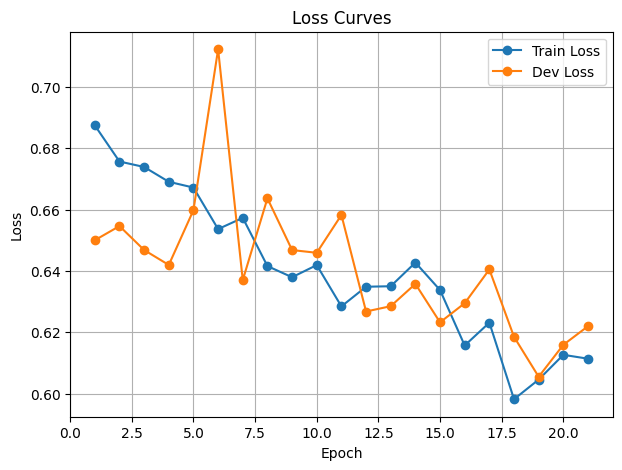

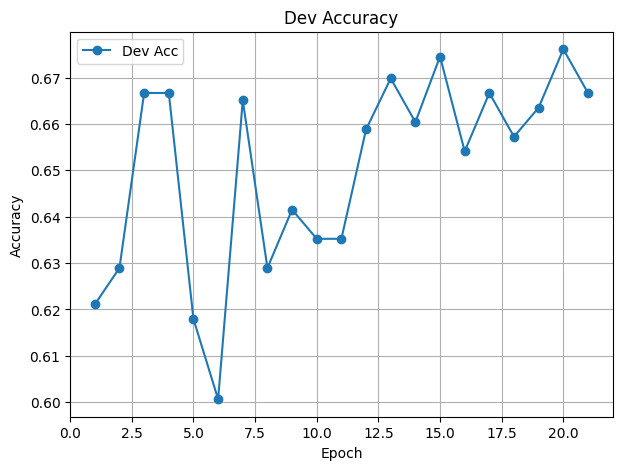

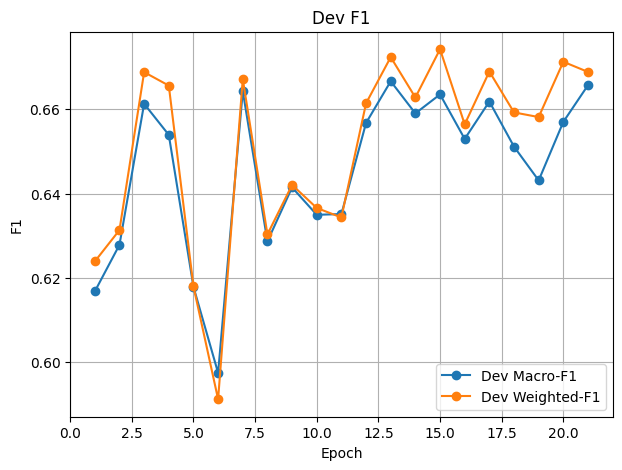

In [12]:
# ============================================
# 9) Curves
# ============================================
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["dev_loss"], marker="o", label="Dev Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curves")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["dev_acc"], marker="o", label="Dev Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Dev Accuracy")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["dev_f1_macro"], marker="o", label="Dev Macro-F1")
plt.plot(epochs, history["dev_f1_weighted"], marker="o", label="Dev Weighted-F1")
plt.xlabel("Epoch"); plt.ylabel("F1"); plt.title("Dev F1")
plt.grid(True); plt.legend(); plt.show()


DEV:
acc=0.6698 f1_macro=0.6666 f1_weighted=0.6724
                 precision    recall  f1-score   support

not_informative       0.75      0.65      0.70       374
    informative       0.58      0.69      0.63       262

       accuracy                           0.67       636
      macro avg       0.67      0.67      0.67       636
   weighted avg       0.68      0.67      0.67       636



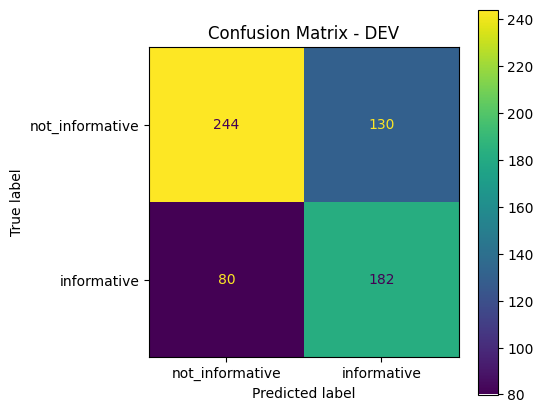


TEST:
acc=0.7073 f1_macro=0.7035 f1_weighted=0.7082
                 precision    recall  f1-score   support

not_informative       0.76      0.72      0.74       360
    informative       0.65      0.69      0.67       272

       accuracy                           0.71       632
      macro avg       0.70      0.71      0.70       632
   weighted avg       0.71      0.71      0.71       632



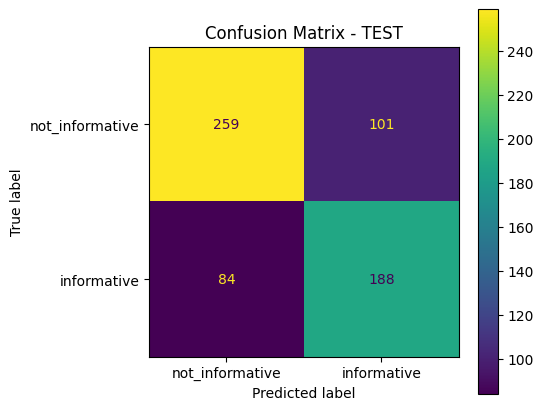

In [13]:
# ============================================
# 10) Confusion matrices (FIXED)
# ============================================
def show_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["not_informative", "informative"])
    fig, ax = plt.subplots(figsize=(5,5))
    disp.plot(values_format="d", ax=ax)
    ax.set_title(title)
    plt.show()

# DEV
dv_loss, dv_acc, (pw, rw, f1w), (pm, rm, f1m), ydv, pdv = evaluate(model, dev_loader)
print("\nDEV:")
print(f"acc={dv_acc:.4f} f1_macro={f1m:.4f} f1_weighted={f1w:.4f}")
print(classification_report(ydv, pdv, target_names=["not_informative","informative"], zero_division=0))
show_confusion(ydv, pdv, "Confusion Matrix - DEV")

# TEST
ts_loss, ts_acc, (pw, rw, f1w), (pm, rm, f1m), yts, pts = evaluate(model, test_loader)
print("\nTEST:")
print(f"acc={ts_acc:.4f} f1_macro={f1m:.4f} f1_weighted={f1w:.4f}")
print(classification_report(yts, pts, target_names=["not_informative","informative"], zero_division=0))
show_confusion(yts, pts, "Confusion Matrix - TEST")

In [14]:
# ============================================
# 11) Save (Drive)
# ============================================
save_path = os.path.join(OUT_DIR, "disasternet_v2_fromscratch.pt")
torch.save(model.state_dict(), save_path)

with open(os.path.join(OUT_DIR, "label_map.json"), "w") as f:
    json.dump({"label2id": LABEL_MAP, "id2label": {str(k): v for k,v in ID2LABEL.items()}}, f, indent=2)

with open(os.path.join(OUT_DIR, "config.json"), "w") as f:
    json.dump({
        "model_name": "DisasterNet v2 (from scratch, SE + AttentionPool, MixUp, Warmup+Cosine)",
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs_trained": len(history["train_loss"]),
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "mixup_alpha": MIXUP_ALPHA,
        "seed": SEED,
        "train_csv": TRAIN_CSV,
        "dev_csv": DEV_CSV,
        "test_csv": TEST_CSV,
        "image_root": IMAGE_ROOT
    }, f, indent=2)

print("✅ Saved:", save_path)

✅ Saved: /content/drive/MyDrive/TASK01/models/custom_task1a_image_fromscratch_v2/disasternet_v2_fromscratch.pt


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as T
import os, json
import numpy as np

# ✅ set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ----------------------------
# Put YOUR saved folder here
# ----------------------------
OUT_DIR = "/content/drive/MyDrive/TASK01/models/custom_task1a_image_fromscratch_v2"
MODEL_PATH = os.path.join(OUT_DIR, "disasternet_v2_fromscratch.pt")
LABEL_MAP_PATH = os.path.join(OUT_DIR, "label_map.json")

# ----------------------------
# Same IMG_SIZE you trained with
# ----------------------------
IMG_SIZE = 224

eval_tfms = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

# ----------------------------
# Model definition (MUST match training)
# ----------------------------
class SEBlock(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.fc1 = nn.Conv2d(ch, max(1, ch // r), 1)
        self.fc2 = nn.Conv2d(max(1, ch // r), ch, 1)

    def forward(self, x):
        s = F.adaptive_avg_pool2d(x, 1)
        s = F.relu(self.fc1(s), inplace=True)
        s = torch.sigmoid(self.fc2(s))
        return x * s

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, drop=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.se    = SEBlock(out_ch, r=16)
        self.drop  = nn.Dropout2d(drop) if drop > 0 else nn.Identity()

        self.shortcut = nn.Identity()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)), inplace=True)
        h = self.drop(h)
        h = self.bn2(self.conv2(h))
        h = self.se(h)
        return F.relu(h + self.shortcut(x), inplace=True)

class AttentionPool2d(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.attn = nn.Conv2d(in_ch, 1, 1)

    def forward(self, x):
        a = self.attn(x)          # [B,1,H,W]
        a = a.flatten(2)          # [B,1,HW]
        a = torch.softmax(a, -1)  # weights
        xf = x.flatten(2)         # [B,C,HW]
        pooled = (xf * a).sum(-1) # [B,C]
        return pooled, a

class DisasterNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.stage1 = nn.Sequential(
            ResidualBlock(32, 64, stride=2, drop=0.05),
            ResidualBlock(64, 64, stride=1, drop=0.05),
        )
        self.stage2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2, drop=0.10),
            ResidualBlock(128, 128, stride=1, drop=0.10),
        )
        self.stage3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2, drop=0.15),
            ResidualBlock(256, 256, stride=1, drop=0.15),
        )
        self.stage4 = nn.Sequential(
            ResidualBlock(256, 384, stride=2, drop=0.20),
            ResidualBlock(384, 384, stride=1, drop=0.20),
        )
        self.attn_pool = AttentionPool2d(384)
        self.head = nn.Sequential(
            nn.LayerNorm(384),
            nn.Linear(384, 256),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        pooled, _ = self.attn_pool(x)
        logits = self.head(pooled)
        return logits

# ----------------------------
# Load label map
# ----------------------------
with open(LABEL_MAP_PATH, "r") as f:
    lm = json.load(f)

id2label = {int(k): v for k, v in lm["id2label"].items()}
print("id2label:", id2label)

# ----------------------------
# Load weights
# ----------------------------
model = DisasterNet(num_classes=2).to(device)
state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

print("✅ Model loaded:", MODEL_PATH)

# ----------------------------
# Predict function
# ----------------------------
@torch.no_grad()
def predict_image(image_path: str):
    img = Image.open(image_path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_id = int(probs.argmax())
    return pred_id, id2label[pred_id], probs

# ----------------------------
# TEST with your image path
# ----------------------------
TEST_IMAGE_PATH = "/content/drive/MyDrive/TASK01/data/sample_ss.jpg"  # <-- change this
pred_id, pred_label, probs = predict_image(TEST_IMAGE_PATH)

print("Image:", TEST_IMAGE_PATH)
print("Predicted:", pred_id, pred_label)
print("Prob not_informative:", float(probs[0]))
print("Prob informative    :", float(probs[1]))

Device: cuda
id2label: {0: 'not_informative', 1: 'informative'}
✅ Model loaded: /content/drive/MyDrive/TASK01/models/custom_task1a_image_fromscratch_v2/disasternet_v2_fromscratch.pt
Image: /content/drive/MyDrive/TASK01/data/sample_ss.jpg
Predicted: 0 not_informative
Prob not_informative: 0.8651048541069031
Prob informative    : 0.13489514589309692
